<a href="https://colab.research.google.com/github/nshanbhag2003/ML-Pipelines/blob/main/AMLHW1Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 7: Comparing Lloyd's algorithm and Projection-based Clustering

## Random Data Generation

In [ ]:
import numpy as np

dim = 9

def data_generator(seed, n, dim):

  mu1 = [1 , 1 , 1 , 0 , 0 , 0 , 0 , 0 , 0]
  mu2 = [0 , 0 , 0 , 0 , 0 , 0 , 1 , 1 , 1]
  mu3 = [0 , 0 , 0 , 1 , 1 , 1 , 0 , 0 , 0]

  sigma1 = np.diag([1, 1, 1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])
  sigma2 = np.diag([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 1, 1, 1])
  sigma3 = np.diag([0.1, 0.1, 0.1, 1, 1, 1, 0.1, 0.1, 0.1])

  np.random.seed(seed)
  rand_int = np.random.choice([1,2,3], size = n)

  unique_values, counts = np.unique(rand_int, return_counts=True)

  datapoints = np.zeros((0, dim))
  labels = np.array([])

  for i, (uv, mu, sigma) in enumerate(zip(unique_values, [mu1, mu2, mu3], [sigma1, sigma2, sigma3])):
    datapoints = np.vstack((datapoints, np.random.multivariate_normal(mu, sigma,
                                                                      size = counts[i])))
    labels = np.hstack((labels, uv * np.ones(counts[i])))

  shuff = np.random.permutation(len(labels))

  return datapoints[shuff], labels[shuff]

## Part a

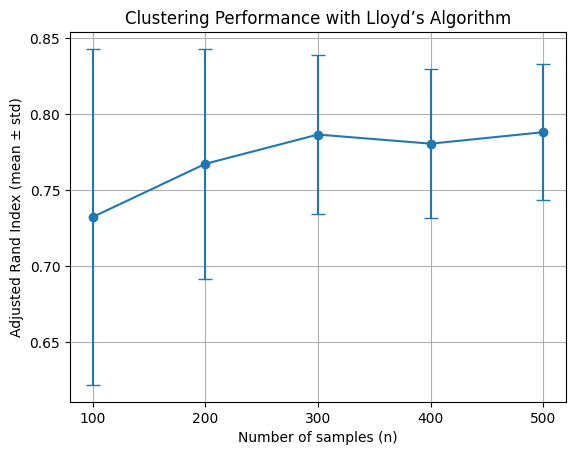

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import warnings

warnings.filterwarnings('ignore')

# Iterate over these values of n
n_values = [100, 200, 300, 400, 500]
means, stds = [], []

for n in n_values:
    ari_scores = []
    for seed in range(1, 101):  # 100 datasets
        X, y_true = data_generator(seed, n, dim)
        # K-means and ARI
        kmeans = KMeans(n_clusters=3, n_init=10, random_state=seed)
        y_pred = kmeans.fit_predict(X)
        ari = adjusted_rand_score(y_true, y_pred)
        ari_scores.append(ari)
    means.append(np.mean(ari_scores))
    stds.append(np.std(ari_scores))

# Plot results
plt.errorbar(n_values, means, yerr=stds, fmt='-o', capsize=5)
plt.xticks(n_values)
plt.xlabel("Number of samples (n)")
plt.ylabel("Adjusted Rand Index (mean ± std)")
plt.title("Clustering Performance with Lloyd’s Algorithm")
plt.grid(True)
plt.show()

## Part b

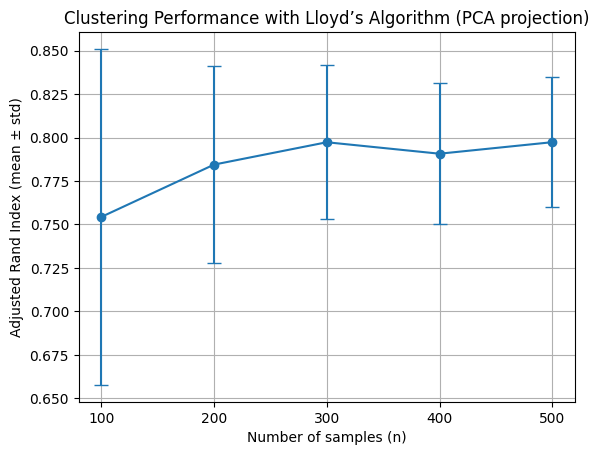

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

# Iterate over these values of n
n_values = [100, 200, 300, 400, 500]
means_pca, stds_pca = [], []

for n in n_values:
    ari_scores = []
    for seed in range(1, 101):  # 100 datasets
        X, y_true = data_generator(seed, n, dim)

        # PCA projection onto top 3 PCs
        pca = PCA(n_components=3, random_state=seed)
        X_pca = pca.fit_transform(X)

        # Run k-means now
        kmeans = KMeans(n_clusters=3, n_init=10, random_state=seed)
        y_pred = kmeans.fit_predict(X_pca)

        # Rand Index
        ari = adjusted_rand_score(y_true, y_pred)
        ari_scores.append(ari)

    means_pca.append(np.mean(ari_scores))
    stds_pca.append(np.std(ari_scores))

# Plot results
plt.errorbar(n_values, means_pca, yerr=stds_pca, fmt='-o', capsize=5)
plt.xticks(n_values)
plt.xlabel("Number of samples (n)")
plt.ylabel("Adjusted Rand Index (mean ± std)")
plt.title("Clustering Performance with Lloyd’s Algorithm (PCA projection)")
plt.grid(True)
plt.show()


## Part c

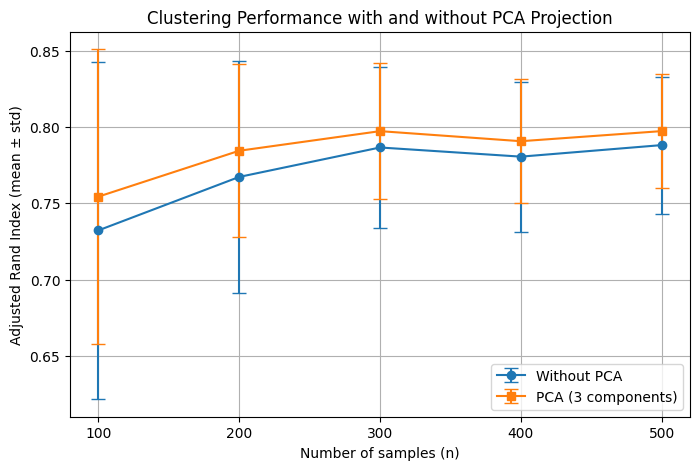

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Original data
plt.errorbar(n_values, means, yerr=stds, fmt='-o', capsize=5, label="Without PCA")

# PCA projected data
plt.errorbar(n_values, means_pca, yerr=stds_pca, fmt='-s', capsize=5, label="PCA (3 components)")

# Superimposed plots
plt.xticks(n_values)
plt.xlabel("Number of samples (n)")
plt.ylabel("Adjusted Rand Index (mean ± std)")
plt.title("Clustering Performance with and without PCA Projection")
plt.legend()
plt.grid(True)
plt.show()


# Problem 8: Comparing K-means, Meanshift and Spectral Clustering on synthetic data

## Generating the 3 datasets

In [1]:
import numpy as np
import random
import math
random.seed(0)

##Data set 1
X1 = []
for i in range(1000):
    theta = random.uniform(0, 2 * math.pi)
    radius = random.gauss(0, 0.2) + random.choice([1, 3])
    X1.append([radius * math.cos(theta), radius * math.sin(theta)])
X1 = np.array(X1)

##Data Set 2
X2 = []
for i in range(1000):
    theta = random.uniform(0, 2 * math.pi)
    radius = random.gauss(0, 0.1) + 2
    if theta < math.pi:
        X2.append([radius * math.cos(theta) - 1, radius * math.sin(theta)])
    else:
        X2.append([radius * math.cos(theta) + 1, radius * math.sin(theta)])
X2 = np.array(X2)

##Data Set 3
X3 = []
for i in range(1000):
    radius = random.gauss(0, 1)
    theta = random.uniform(0, 2 * math.pi)
    center = random.choice([[0, 1], [3, 3], [1, -3]])
    X3.append([
        radius * math.cos(theta) + center[0],
        radius * math.sin(theta) + center[1]
    ])
X3 = np.array(X3)

## Plotting Clusters Helper Function

In [2]:
# # assume ’ label_pred ’ is list of group labels , use following code as a
# reference for plotting the result .
import matplotlib.pyplot as plt

def plot_clusters(X, labels, title):
    mark = ['or', 'ob', 'oy', 'g', 'c', 'm', 'k', 'w']
    j = 0
    for i in labels:
        plt.plot([X[j:j+1, 0]], [X[j:j+1, 1]], mark[i % len(mark)], markersize=5)
        j += 1
    plt.ylabel('Dimension 1')
    plt.xlabel('Dimension 2')
    plt.title(title)
    plt.show()


## Part a - c


--- (a) KMeans ---


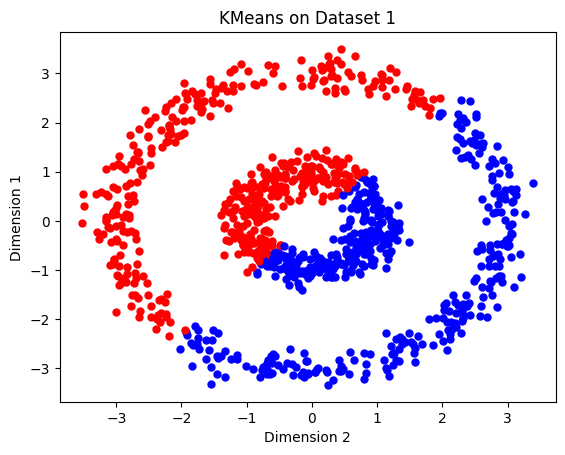

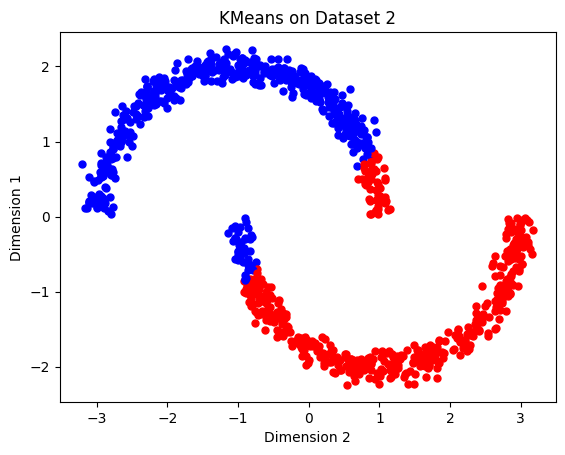

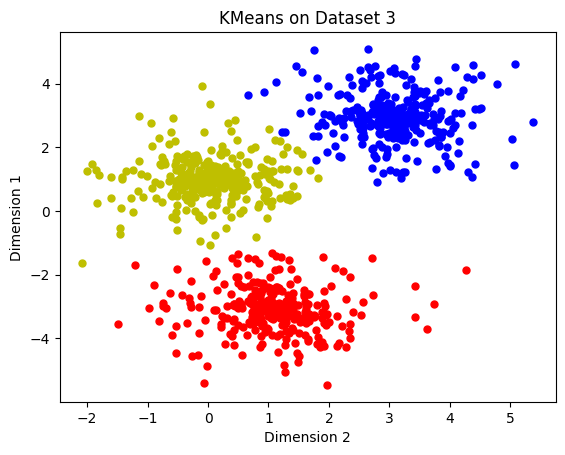

In [3]:
from sklearn.cluster import KMeans, MeanShift, SpectralClustering
from sklearn.metrics import pairwise_distances

# Set K = 2 for case-1,2 and K = 3 for case-3 in using K-means and Spectral clustering
datasets = [(X1, 2, "Dataset 1"), (X2, 2, "Dataset 2"), (X3, 3, "Dataset 3")]

# (a) KMeans
print("\n--- (a) KMeans ---")
for X, k, name in datasets:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(X)
    plot_clusters(X, kmeans.labels_, f"KMeans on {name}")


--- (b) MeanShift ---


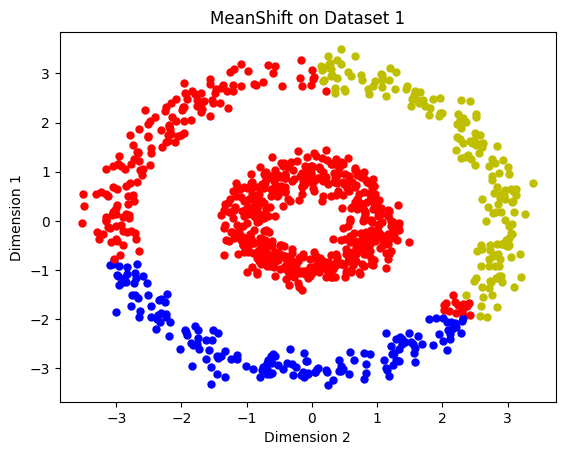

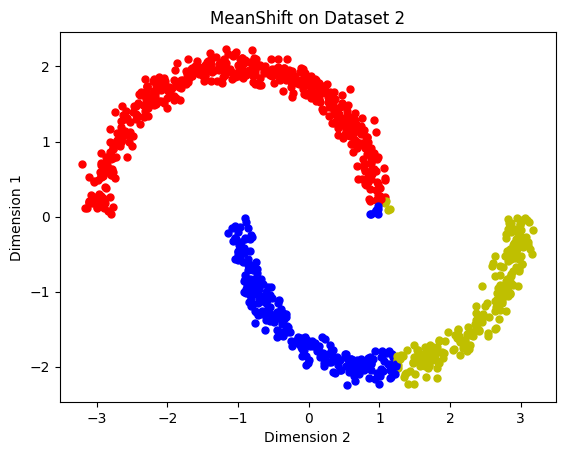

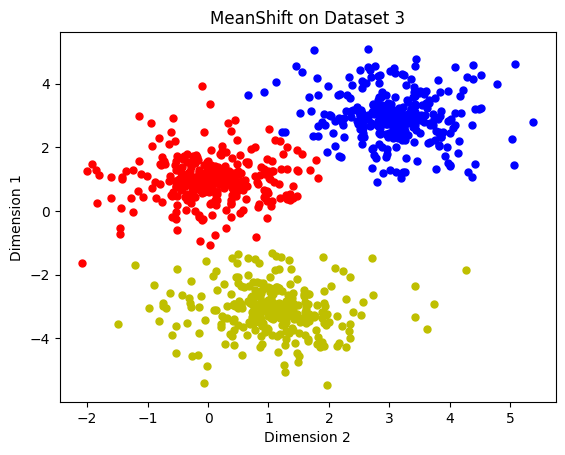

In [4]:
# (b) MeanShift
print("\n--- (b) MeanShift ---")
for X, k, name in datasets:
    dists = pairwise_distances(X)
    bandwidth = np.quantile(dists, 0.2)
    meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True).fit(X)
    plot_clusters(X, meanshift.labels_, f"MeanShift on {name}")


--- (c) Spectral Clustering ---


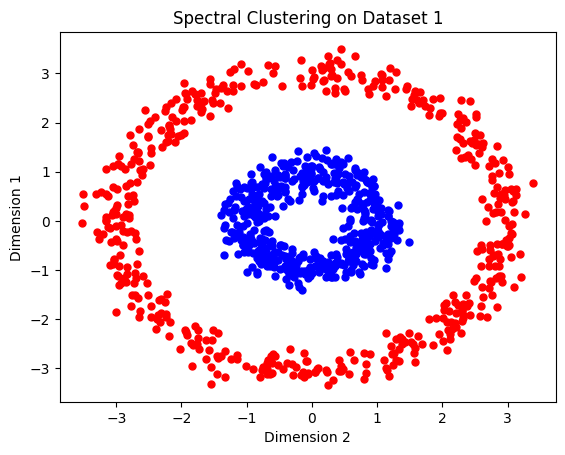

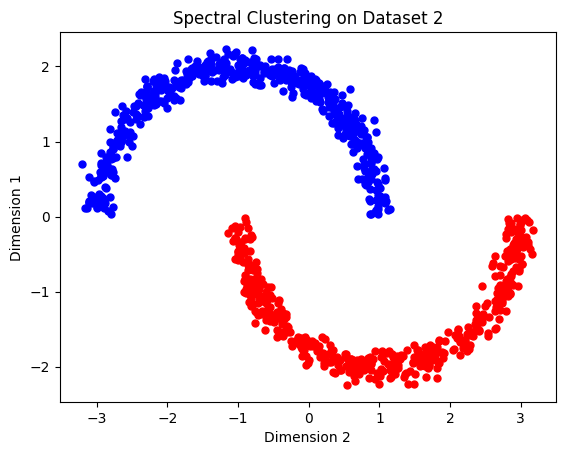

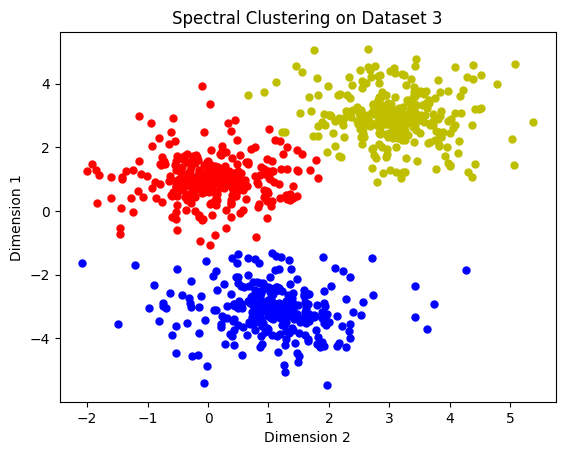

In [5]:
# (c) Spectral Clustering
print("\n--- (c) Spectral Clustering ---")
for X, k, name in datasets:
    spectral = SpectralClustering(n_clusters=k, assign_labels="kmeans", random_state=0).fit(X)
    plot_clusters(X, spectral.labels_, f"Spectral Clustering on {name}")